# Modélisation causale — Effet d'un coureur sur les points UCI de son équipe

**Méthode :** Double Machine Learning (DML) + Causal Forest DML  
**Traitement :** `selected` (présence du coureur sur la course)  
**Outcome :** `pts_uci_equipe` (points UCI de l'équipe)  
**Objectif :** Estimer l'effet causal de la présence d'un coureur, puis analyser l'hétérogénéité de cet effet selon le type de course

In [77]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from econml.dml import CausalForestDML
warnings.filterwarnings('ignore')

RIDER_DIR  = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'
RACE_PATH  = '/Users/arthurdeletang/Desktop/Stage M1/Code/race_data/race_features.csv'

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Chargement et jointure des données

In [122]:
def load_rider(rider_filename, race_path=RACE_PATH):
    """
    Charge un fichier coureur, joint avec race_features.csv
    sur course + year + stage_num, et prepare le dataset pour la modelisation.
    """
    df_rider = pd.read_csv(os.path.join(RIDER_DIR, rider_filename))
    df_race  = pd.read_csv(race_path)

    # Preparation des cles de jointure
    df_rider['stage_num'] = pd.to_numeric(df_rider['etape'],    errors='coerce')
    df_rider['year']      = pd.to_numeric(df_rider['year'],     errors='coerce').astype('Int64')
    df_race['year']       = pd.to_numeric(df_race['year'],      errors='coerce').astype('Int64')
    df_race['stage_num']  = pd.to_numeric(df_race['stage_num'], errors='coerce')

    # Jointure
    df_merged = df_rider.merge(
        df_race.drop(columns=['stage', 'classification', 'date'], errors='ignore'),
        on=['course', 'year', 'stage_num'],
        how='left'
    )

    # Reordonner selected apres equipe
    cols = df_merged.columns.tolist()
    if 'selected' in cols:
        cols.remove('selected')
        idx = cols.index('equipe') if 'equipe' in cols else 0
        cols.insert(idx + 1, 'selected')
        df_merged = df_merged[cols]

    no_match = df_merged['distance_gpx_km'].isna().sum()
    print(f'Lignes totales    : {len(df_merged)}')
    print(f'Sans match GPX    : {no_match} ({no_match/len(df_merged)*100:.1f}%)')
    print(f'selected=1        : {(df_merged["selected"]==1).sum()}')
    print(f'selected=0        : {(df_merged["selected"]==0).sum()}')
    return df_merged

# Tester sur Vingegaard
df_merged = load_rider('van_aert_wout.csv')
df_merged.head(200)

Lignes totales    : 1795
Sans match GPX    : 60 (3.3%)
selected=1        : 388
selected=0        : 1407


,date,year,course,type,etape,equipe,selected,classification,statut,rang,...,loc_last_col_cat3,loc_last_col_cat2,loc_last_col_cat1,loc_last_col_hc,gradient_last_1km,gradient_last_3km,gradient_last_5km,denivele_last_5km,gradient_first_50km,denivele_first_50km
0,2017-03-05,2017,3daagse-van-west-vlaanderen,result,NaN,Vérandas Willems-Crelan,0,1.1,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.3,-0.13,-0.26,102.0,0.00,69.0
1,2017-05-09,2017,4-jours-de-dunkerque,stage,1.0,Vérandas Willems-Crelan,0,2.HC,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0,0.00,0.00,0.0,0.00,0.0
2,2017-05-10,2017,4-jours-de-dunkerque,stage,2.0,Vérandas Willems-Crelan,0,2.HC,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0,0.00,0.00,0.0,0.00,0.0
3,2017-05-11,2017,4-jours-de-dunkerque,stage,3.0,Vérandas Willems-Crelan,0,2.HC,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0,0.00,0.00,0.0,0.00,0.0
4,2017-05-12,2017,4-jours-de-dunkerque,stage,4.0,Vérandas Willems-Crelan,0,2.HC,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0,0.00,0.00,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2018-07-10,2018,tour-of-austria,stage,4.0,Vérandas Willems-Crelan,1,2.1,FIN,2.0,...,0.9996,0.9996,0.9996,0.4165,1.3,0.53,0.24,463.0,1.45,1402.0
196,2018-07-11,2018,tour-of-austria,stage,5.0,Vérandas Willems-Crelan,1,2.1,FIN,76.0,...,0.9992,0.9992,0.9992,0.9992,7.1,9.07,9.40,507.0,-0.42,751.0
197,2018-07-12,2018,tour-of-austria,stage,6.0,Vérandas Willems-Crelan,1,2.1,FIN,7.0,...,0.9608,0.9608,0.4271,0.0000,2.8,1.23,-1.88,379.0,-0.28,254.0
198,2018-07-13,2018,tour-of-austria,stage,7.0,Vérandas Willems-Crelan,1,2.1,FIN,79.0,...,0.9996,0.9996,0.0000,0.0000,12.6,10.23,6.86,386.0,0.67,1171.0


## 2. Préparation du dataset de modélisation

In [123]:
def prepare_model_data(df_merged):
    """
    Prepare le dataset pour le DML :
    - Selectionne les features GPX + contextuelles
    - Encode les variables categorielle
    - Supprime les lignes sans features GPX
    """
    features_gpx = [
        'distance_gpx_km', 'denivele_pos', 'denivele_neg',
        'altitude_max', 'altitude_min',
        'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
        'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc',
        'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
        'denivele_last_5km',
        'gradient_first_50km', 'denivele_first_50km',
        'cobblestones_km', 'compacted_gravel_km',
    ]
    features_gpx = [f for f in features_gpx if f in df_merged.columns]

    df = df_merged.copy()

    # Encodage classification
    le = LabelEncoder()
    df['classification_enc'] = le.fit_transform(df['classification'].fillna('unknown'))

    features_all = features_gpx

    df_model = df[features_all + ['selected', 'pts_uci_equipe', 'pts_uci']].dropna(subset=features_gpx)

    print(f'Shape dataset modele : {df_model.shape}')
    print(f'Features             : {features_all}')
    print(f'NaN restants         : {df_model[features_all].isna().sum().sum()}')

    return df_model, features_all

df_model, features_all = prepare_model_data(df_merged)

# Apercu de la distribution de l'outcome
print(f'\nOutcome pts_uci_equipe :')
print(df_model.groupby('selected')['pts_uci_equipe'].describe().round(2))

Shape dataset modele : (1735, 24)
Features             : ['distance_gpx_km', 'denivele_pos', 'denivele_neg', 'altitude_max', 'altitude_min', 'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc', 'loc_last_col_cat2', 'loc_last_col_cat1', 'loc_last_col_hc', 'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km', 'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km', 'cobblestones_km', 'compacted_gravel_km']
NaN restants         : 0

Outcome pts_uci_equipe :
           count    mean     std   min  25%   50%    75%     max
selected                                                        
0         1354.0   29.78   69.56 -25.0  0.0   0.0   25.0   570.0
1          381.0  110.68  177.79   0.0  0.0  47.0  140.0  1290.0


## 3. Double Machine Learning (DML) — ATE

In [124]:
def run_dml(df_model, features_all, outcome='pts_uci_equipe', n_folds=5, n_boot=1000):
    """
    Estime l'ATE par Double Machine Learning avec bootstrap pour l'IC 95%.
    Outcome log-transforme pour gerer la distribution asymetrique.
    """
    X = df_model[features_all].values
    T = df_model['selected'].values
    Y = np.log1p(np.clip(df_model[outcome].values, 0, None))

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    T_resid = np.zeros(len(T))
    Y_resid = np.zeros(len(Y))

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        T_tr, T_val = T[train_idx], T[val_idx]
        Y_tr, Y_val = Y[train_idx], Y[val_idx]

        clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
        clf.fit(X_tr, T_tr)
        T_resid[val_idx] = T_val - clf.predict_proba(X_val)[:, 1]

        reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
        reg.fit(X_tr, Y_tr)
        Y_resid[val_idx] = Y_val - reg.predict(X_val)

    # ATE
    ate = np.cov(Y_resid, T_resid)[0, 1] / np.var(T_resid)

    # Bootstrap IC 95%
    ate_boot = []
    for _ in range(n_boot):
        idx = np.random.choice(len(T_resid), len(T_resid), replace=True)
        ate_b = np.cov(Y_resid[idx], T_resid[idx])[0, 1] / np.var(T_resid[idx])
        ate_boot.append(ate_b)
    ci_low, ci_high = np.percentile(ate_boot, [2.5, 97.5])

    # Retour sur echelle originale
    ate_orig     = np.expm1(ate)
    ci_low_orig  = np.expm1(ci_low)
    ci_high_orig = np.expm1(ci_high)

    # Effet brut pour comparaison
    mean_with    = df_model[df_model['selected']==1][outcome].mean()
    mean_without = df_model[df_model['selected']==0][outcome].mean()
    brut = mean_with - mean_without

    results = {
        'ate_log': ate, 'ci_low_log': ci_low, 'ci_high_log': ci_high,
        'ate_orig': ate_orig, 'ci_low_orig': ci_low_orig, 'ci_high_orig': ci_high_orig,
        'brut': brut, 'T_resid': T_resid, 'Y_resid': Y_resid
    }

    print(f'=== DML — {outcome} ===')
    print(f'N lignes      : {len(T)} ({T.sum()} selected=1)')
    print(f'ATE (log)     : {ate:.4f}  IC95% [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'ATE (original): +{ate_orig:.2f} pts  IC95% [{ci_low_orig:.2f}, {ci_high_orig:.2f}]')
    print(f'Effet brut    : +{brut:.2f} pts')
    if ci_low > 0:
        print(f'→ Effet positif significatif')
    elif ci_high < 0:
        print(f'→ Effet negatif significatif')
    else:
        print(f'→ Effet non significatif (IC contient 0)')

    return results

res_equipe = run_dml(df_model, features_all, outcome='pts_uci_equipe')
print()
res_indiv  = run_dml(df_model, features_all, outcome='pts_uci')

=== DML — pts_uci_equipe ===
N lignes      : 1735 (381 selected=1)
ATE (log)     : 1.1476  IC95% [0.9227, 1.3889]
ATE (original): +2.15 pts  IC95% [1.52, 3.01]
Effet brut    : +80.90 pts
→ Effet positif significatif

=== DML — pts_uci ===
N lignes      : 1735 (381 selected=1)
ATE (log)     : 1.8138  IC95% [1.5990, 2.0254]
ATE (original): +5.13 pts  IC95% [3.95, 6.58]
Effet brut    : +59.93 pts
→ Effet positif significatif


## 4. Causal Forest DML — Hétérogénéité de l'effet (CATE)

In [125]:
X = df_model[features_all].values
T = df_model['selected'].values
Y = np.log1p(np.clip(df_model['pts_uci_equipe'].values, 0, None))

cf = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),  # Regressor ici
    n_estimators=500,
    random_state=42,
    cv=5
)
cf.fit(Y, T, X=X)

cate = cf.effect(X)
df_model = df_model.copy()
df_model['cate'] = cate

print(f'CATE moyen (ATE) : {cate.mean():.4f}')
print(f'CATE std         : {cate.std():.4f}')
print(f'CATE min         : {cate.min():.4f}')
print(f'CATE max         : {cate.max():.4f}')
print(f'\nDistribution CATE :')
print(pd.Series(cate).describe().round(4))

CATE moyen (ATE) : 1.1231
CATE std         : 0.3268
CATE min         : -0.1840
CATE max         : 1.9340

Distribution CATE :
count    1735.0000
mean        1.1231
std         0.3269
min        -0.1840
25%         0.9290
50%         1.1537
75%         1.3482
max         1.9340
dtype: float64


## 5. Visualisation de l'hétérogénéité

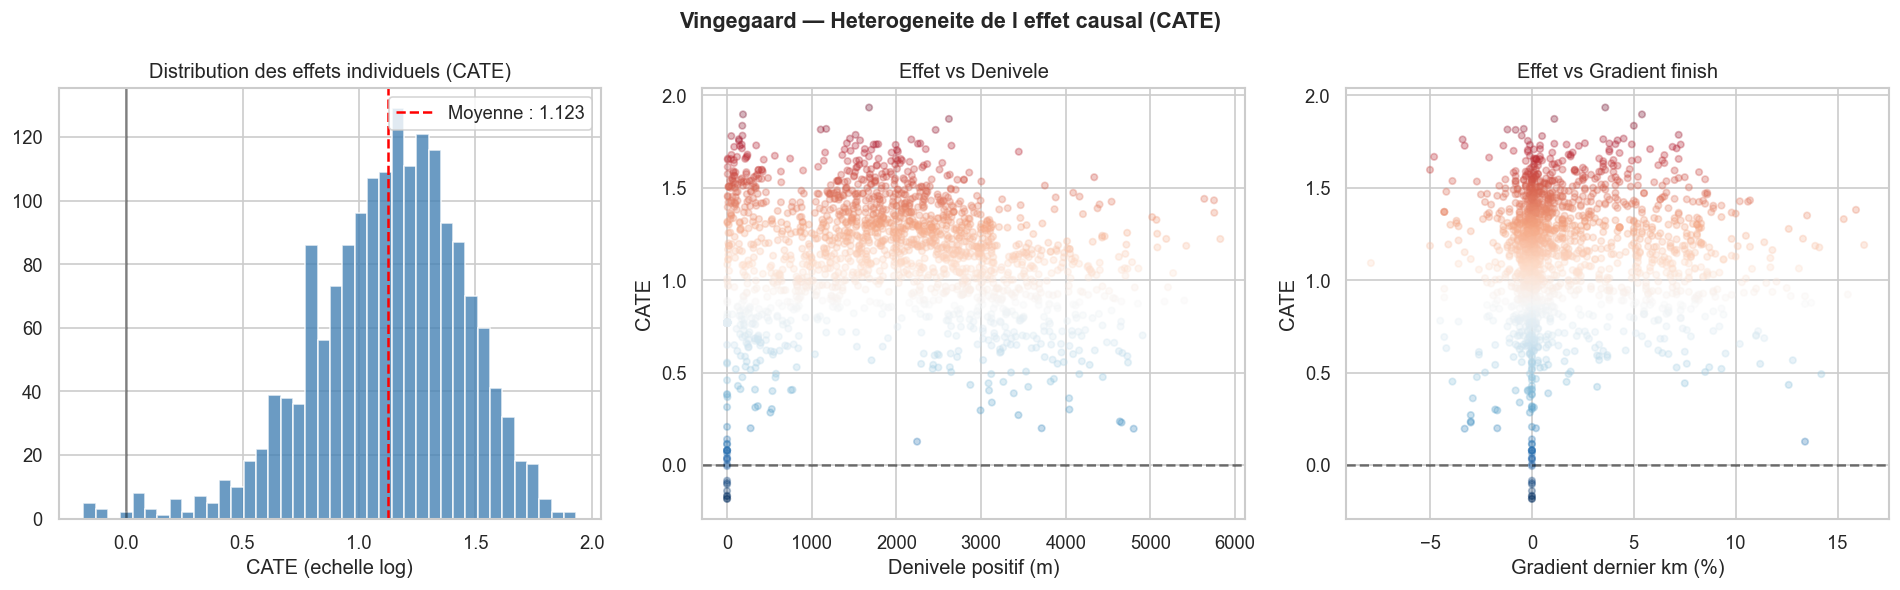

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution des CATE
axes[0].hist(cate, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(cate.mean(), color='red', linestyle='--', label=f'Moyenne : {cate.mean():.3f}')
axes[0].axvline(0, color='black', linestyle='-', alpha=0.4)
axes[0].set_title('Distribution des effets individuels (CATE)')
axes[0].set_xlabel('CATE (echelle log)')
axes[0].legend()

# CATE vs denivele
axes[1].scatter(df_model['denivele_pos'], cate, alpha=0.3, s=15, c=cate, cmap='RdBu_r')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Denivele positif (m)')
axes[1].set_ylabel('CATE')
axes[1].set_title('Effet vs Denivele')

# CATE vs gradient dernier km
axes[2].scatter(df_model['gradient_last_1km'], cate, alpha=0.3, s=15, c=cate, cmap='RdBu_r')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Gradient dernier km (%)')
axes[2].set_ylabel('CATE')
axes[2].set_title('Effet vs Gradient finish')

plt.suptitle('Vingegaard — Heterogeneite de l effet causal (CATE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

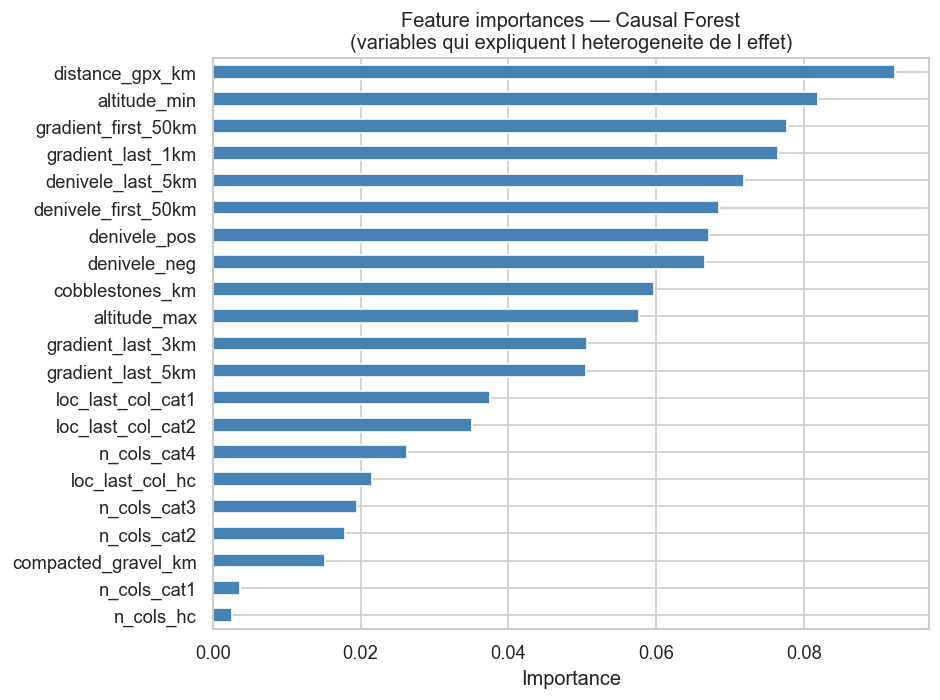

Top 5 features expliquant l heterogeneite :
distance_gpx_km        0.092235
altitude_min           0.081901
gradient_first_50km    0.077677
gradient_last_1km      0.076477
denivele_last_5km      0.071812
dtype: float64


In [127]:
# Importance des features pour l'heterogeneite
importances = cf.feature_importances_
feat_imp = pd.Series(importances, index=features_all).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importances — Causal Forest\n(variables qui expliquent l heterogeneite de l effet)', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 5 features expliquant l heterogeneite :')
print(feat_imp.sort_values(ascending=False).head(5))

CATE moyen par quartile de denivele :
                     mean     std  count
denivele_quartile                       
Q1 (plat)          1.0335  0.4285    434
Q2                 1.2635  0.2406    434
Q3                 1.2147  0.2493    433
Q4 (montagne)      0.9809  0.2606    434


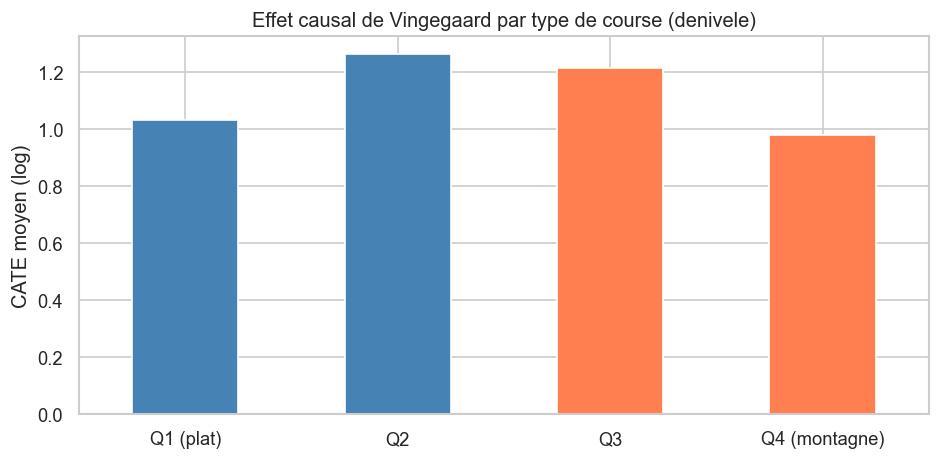

In [128]:
# CATE moyen par quartile de denivele
df_model['denivele_quartile'] = pd.qcut(df_model['denivele_pos'], q=4,
    labels=['Q1 (plat)', 'Q2', 'Q3', 'Q4 (montagne)'])

cate_by_deniv = df_model.groupby('denivele_quartile')['cate'].agg(['mean', 'std', 'count'])
print('CATE moyen par quartile de denivele :')
print(cate_by_deniv.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
cate_by_deniv['mean'].plot(kind='bar', ax=ax, color=['steelblue','steelblue','coral','coral'],
                           edgecolor='white')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Effet causal de Vingegaard par type de course (denivele)', fontsize=12)
ax.set_ylabel('CATE moyen (log)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Résumé des résultats

In [129]:
print('=' * 55)
print('RÉSUMÉ — Vingegaard Jonas')
print('=' * 55)
print(f'N observations          : {len(df_model)}')
print(f'dont selected=1         : {(df_model["selected"]==1).sum()}')
print()
print('--- DML (ATE) ---')
print(f'pts_uci_equipe  ATE     : +{res_equipe["ate_orig"]:.2f} pts')
print(f'                IC 95%  : [{res_equipe["ci_low_orig"]:.2f}, {res_equipe["ci_high_orig"]:.2f}]')
print(f'                Brut    : +{res_equipe["brut"]:.2f} pts')
print()
print(f'pts_uci indiv   ATE     : +{res_indiv["ate_orig"]:.2f} pts')
print(f'                IC 95%  : [{res_indiv["ci_low_orig"]:.2f}, {res_indiv["ci_high_orig"]:.2f}]')
print()
print('--- Causal Forest (CATE) ---')
print(f'CATE moyen              : {cate.mean():.4f}')
print(f'CATE std                : {cate.std():.4f}')
print(f'Top feature heterogeneite : {feat_imp.sort_values(ascending=False).index[0]}')
print('=' * 55)

RÉSUMÉ — Vingegaard Jonas
N observations          : 1735
dont selected=1         : 381

--- DML (ATE) ---
pts_uci_equipe  ATE     : +2.15 pts
                IC 95%  : [1.52, 3.01]
                Brut    : +80.90 pts

pts_uci indiv   ATE     : +5.13 pts
                IC 95%  : [3.95, 6.58]

--- Causal Forest (CATE) ---
CATE moyen              : 1.1231
CATE std                : 0.3268
Top feature heterogeneite : distance_gpx_km


In [132]:
import os
import pandas as pd

RIDER_DIR = '/Users/arthurdeletang/Desktop/Stage M1/Code/rider_data'

# Chercher les coureurs Groupama-FDJ
riders = os.listdir(RIDER_DIR)

# Charger un coureur et filtrer sur l'equipe et l'annee
sample = pd.read_csv(os.path.join(RIDER_DIR, 'grégoire_romain.csv'))
print(sample[sample['year'] == 2025]['equipe'].unique())
print(sample[sample['year'] == 2025].shape)

# Chercher tous les coureurs Groupama 2025
fdj_riders = []
for f in riders:
    try:
        df = pd.read_csv(os.path.join(RIDER_DIR, f))
        equipes = df[df['year'] == 2025]['equipe'].unique()
        if any('Groupama' in str(e) or 'FDJ' in str(e) for e in equipes):
            fdj_riders.append(f)
    except:
        pass

print(f'\nCoureurs Groupama-FDJ 2025 trouves : {len(fdj_riders)}')
print(fdj_riders)

['Groupama - FDJ' 'France']
(274, 18)

Coureurs Groupama-FDJ 2025 trouves : 38
['loulergue_victor.csv', 'martin_guillaume.csv', 'penhoët_paul.csv', 'braz_afonso_clément.csv', 'gaudu_david.csv', 'agnoletto_blake.csv', 'barthe_cyril.csv', 'geniets_kevin.csv', 'kayser_aurélien.csv', 'rolland_brieuc.csv', 'germani_lorenzo.csv', 'jacobs_johan.csv', 'walls_matthew.csv', 'bower_lewis.csv', 'grégoire_romain.csv', 'molard_rudy.csv', 'cushway_maximilian.csv', 'le_huitouze_eddy.csv', 'roberts_reef.csv', 'bock_max.csv', 'küng_stefan.csv', 'bystrøm_sven_erik.csv', 'madouas_valentin.csv', 'le_gac_olivier.csv', 'cavagna_rémi.csv', 'davy_clément.csv', 'donnenwirth_tom.csv', 'rochas_rémy.csv', 'gruel_thibaud.csv', 'pacher_quentin.csv', 'decomble_maxime.csv', 'fontaine_titouan.csv', 'russo_clément.csv', 'daumas_rémi.csv', 'grégoire_baptiste.csv', 'paleni_enzo.csv', 'boulet_eliott.csv', 'askey_lewis.csv']
